In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import skill_metrics as sm
import warnings
from glob import glob
from scipy.stats import wasserstein_distance

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.mpl.geoaxes as cgeo

warnings.filterwarnings("ignore")

In [2]:
# Constants

START_DATE = np.datetime64('2000-01-01T00:00:00.000000000')
END_DATE = np.datetime64('2023-09-30T23:00:00.000000000')
# START_DATE = np.datetime64('2000-01-01T00:00:00.000000000')
# END_DATE = np.datetime64('2010-12-31T23:00:00.000000000')
N_HOURS = (END_DATE - START_DATE) / np.timedelta64(1, 'h') + 1
N_DAYS = np.round((END_DATE - START_DATE) / np.timedelta64(1, 'D'))
print(N_HOURS, N_DAYS)

COVERAGE_THRESHOLD = 0.9
ZSCORE_THRESHOLD = 5  # for outlier detection; may want to adjust (this seems to reject some plausible Wind Spd values, for instance)
vars = [
    "Wind Spd (km/h)",
]

BAD_MONTHS = [[2005, 4],
             [2005, 7],
             [2005, 10],
             [2006, 3],
             [2006, 9],
             [2008, 7],
             [2015, 10],
             [2017, 8],
             [2017, 11],
             [2019, 9],
             [2021, 7],
             [2022, 2],
             [2023, 6]]

full_time_index = pd.Index(
    np.arange(START_DATE, END_DATE + np.timedelta64(1, 'h'), np.timedelta64(1, 'h')),
    name='Date/Time (LST)'
    )

208176.0 8674.0


In [3]:
def readable_time_coord(ds, time_var='Times'):

    time_vals = ds[time_var].values

    # Extract integer (YYYYMMDD) and fractional day parts
    dates_int = time_vals.astype(int)
    frac_days = time_vals - dates_int

    # Parse integers to datetime
    base_dates = pd.to_datetime(dates_int.astype(str), format="%Y%m%d")

    # Add fractional day as timedelta
    full_times = base_dates + pd.to_timedelta(frac_days, unit="D")
    full_times = full_times.round("1h")

    # Assign back to dataset
    ds = ds.assign_coords({time_var: full_times})
    ds = ds.transpose(time_var, ...)

    ds = ds.rename({time_var: "time"})
    
    return ds

# Find the nearest grid point in winds_ds to the station's lat/lon
def get_nearest_wrf_point(ds, lat, lon):
    abs_lat = np.abs(ds['XLAT'] - lat)
    abs_lon = np.abs(ds['XLONG'] - lon)
    dist = abs_lat + abs_lon
    # Find indices of the minimum distance
    idx = np.unravel_index(np.argmin(dist.values), dist.shape)
    return idx

# Open WRF Data

In [4]:
wrf_ubc_static = xr.open_mfdataset("/users/rpayne/data/unproc/WRF-UBC/ubc_wrf_staticfields_d03.nc")
wrf_ubc_static['HGT'] = np.clip(wrf_ubc_static['HGT'], 0., None)
hgt_ubc = wrf_ubc_static['HGT'].values.squeeze()
landmask_ubc = wrf_ubc_static['LANDMASK'].values.squeeze()
lon_ubc = wrf_ubc_static['XLONG'].values.squeeze()
lat_ubc = wrf_ubc_static['XLAT'].values.squeeze()

# DAILY MEAN humid

humid_ds = readable_time_coord(xr.open_dataset("/users/rpayne/data/unproc/WRF-UBC/Q2/Q2_dailymean_199910_202309.nc"))
humid_ds = humid_ds.sel(time=slice(START_DATE, END_DATE)).drop_vars('Times_bnds')

humid_ds

<xarray.Dataset> Size: 13GB
Dimensions:  (south_north: 702, west_east: 558, time: 8566)
Coordinates:
    XLONG    (south_north, west_east) float32 2MB ...
    XLAT     (south_north, west_east) float32 2MB ...
  * time     (time) datetime64[ns] 69kB 2000-01-01T12:00:00 ... 2023-09-30T12...
Dimensions without coordinates: south_north, west_east
Data variables:
    Q2       (time, south_north, west_east) float32 13GB ...
Attributes: (12/91)
    CDI:                             Climate Data Interface version 1.9.9rc1 ...
    Conventions:                     CF-1.6
    history:                         Thu Aug 14 13:42:39 2025: cdo daymean -s...
    TITLE:                            OUTPUT FROM WRF V4.4.2 MODEL
    START_DATE:                      1999-10-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        559
    ...                              ...
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2
    frequency:                       day
    CDO:                             Climate Data Operators version 1.9.9rc1 ...

# Open STN Data

In [5]:
# Takes ~5 minutes to run

wx_data_fnames = sorted(glob("/users/rpayne/data/unproc/STN_ECCC/api/hourly/ec_hourly*.csv"))
df = pd.concat(
    (pd.read_csv(f, encoding='utf8', low_memory=False) for f in wx_data_fnames),
    ignore_index=True
)
df['Date/Time (LST)'] = pd.to_datetime(df['Date/Time (LST)'], format='%Y-%m-%d %H:%M:%S')
df = df[df['Date/Time (LST)'] >= START_DATE]  # Filter for data to align w WRF
df = df[df['Date/Time (LST)'] <= END_DATE]
df.set_index('Date/Time (LST)', inplace=True)
df

,Longitude (x),Latitude (y),Station Name,Climate ID,Year,Month,Day,Time (LST),Flag,Temp (°C),...,Visibility Flag,Stn Press (kPa),Stn Press Flag,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag,Weather,Precip. Amount (mm),Precip. Amount Flag
Date/Time (LST),,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,00:00,NaN,-0.4,...,M,NaN,M,NaN,NaN,-4.0,NaN,NaN,NaN,NaN
2000-01-01 01:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,01:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
2000-01-01 02:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,02:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
2000-01-01 03:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,03:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
2000-01-01 04:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,04:00,NaN,-0.5,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-30 19:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2023,9,30,19:00,NaN,11.9,...,NaN,96.51,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2023-09-30 20:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2023,9,30,20:00,NaN,11.4,...,NaN,96.55,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2023-09-30 21:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2023,9,30,21:00,NaN,10.8,...,NaN,96.59,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [6]:
# Create a dictionary mapping station name to (lat, lon) from df
stn_latlon = {}
stns = df["Station Name"].unique()
for stn in stns:
    stn_rows = df[df["Station Name"] == stn]
    if not stn_rows.empty:
        lat = stn_rows["Latitude (y)"].iloc[0]
        lon = stn_rows["Longitude (x)"].iloc[0]
        stn_latlon[stn] = (lat, lon)
    else:
        stn_latlon[stn] = (None, None)


def get_stn(stn_name, data=df):
    stn = data[data["Station Name"] == stn_name]
    stn = stn.sort_index()
    stn = stn[~stn.index.duplicated(keep='last')]
    stn = stn.reindex(full_time_index)
    return stn

In [7]:
m_v = 18.01528e-3 # kg/mol
m_d = 28.9647e-3 # kg/mol
e0 = 0.611 # kPa
T0 = 273.15 # K
L_v = 2.45e6 # J/kg
R = 8.314 # J/(mol*K)

df["Specific Humidity (kg/kg)"] = np.exp((m_v * L_v / R) * (1/T0 - 1/(df["Dew Point Temp (°C)"] + 273.15))) * (m_v/m_d) * (e0 / df["Stn Press (kPa)"])

In [8]:
# Find all stations that meet the coverage threshold for the given variables

Q2_coverage_dict = {}

for i,stn in enumerate(stns):
    print(f"{i+1}/{len(stns)}")
    
    stn_data = get_stn(stn)

    Q2_data = stn_data["Specific Humidity (kg/kg)"].resample('D').mean()
    Q2_coverage = np.count_nonzero(~np.isnan(Q2_data)) / N_DAYS
    if Q2_coverage >= COVERAGE_THRESHOLD:
        Q2_coverage_dict[stn] = Q2_coverage

Q2_stns = np.sort(list(Q2_coverage_dict.keys()))

print(f"Number of stations with adequate Q2 coverage: {len(Q2_stns)}")

1/203
2/203
3/203
4/203
5/203
6/203
7/203
8/203
9/203
10/203
11/203
12/203
13/203
14/203
15/203
16/203
17/203
18/203
19/203
20/203
21/203
22/203
23/203
24/203
25/203
26/203
27/203
28/203
29/203
30/203
31/203
32/203
33/203
34/203
35/203
36/203
37/203
38/203
39/203
40/203
41/203
42/203
43/203
44/203
45/203
46/203
47/203
48/203
49/203
50/203
51/203
52/203
53/203
54/203
55/203
56/203
57/203
58/203
59/203
60/203
61/203
62/203
63/203
64/203
65/203
66/203
67/203
68/203
69/203
70/203
71/203
72/203
73/203
74/203
75/203
76/203
77/203
78/203
79/203
80/203
81/203
82/203
83/203
84/203
85/203
86/203
87/203
88/203
89/203
90/203
91/203
92/203
93/203
94/203
95/203
96/203
97/203
98/203
99/203
100/203
101/203
102/203
103/203
104/203
105/203
106/203
107/203
108/203
109/203
110/203
111/203
112/203
113/203
114/203
115/203
116/203
117/203
118/203
119/203
120/203
121/203
122/203
123/203
124/203
125/203
126/203
127/203
128/203
129/203
130/203
131/203
132/203
133/203
134/203
135/203
136/203
137/203
138/203
139/

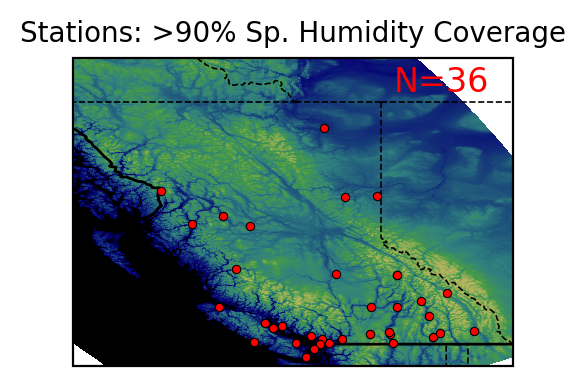

In [9]:
# Create a figure
proj = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=-90.0,
    true_scale_latitude=60.0
)
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()},figsize=(4,2),dpi=200)

# Plot using pcolormesh
mesh = ax.pcolormesh(lon_ubc, lat_ubc, hgt_ubc, transform=ccrs.PlateCarree(), shading='auto', cmap='gist_earth')
ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=1)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=1)
ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=1)
for stn in Q2_coverage_dict.keys():
    lat, lon = stn_latlon[stn]
    ax.scatter(lon, lat, marker='.', facecolor='red', edgecolor='k', linewidth=.4, transform=ccrs.PlateCarree())
ax.set_xlim(-134, -114)
ax.set_ylim(48, 62)
ax.text(-119.4, 60.5, f"N={len(Q2_coverage_dict.keys())}", fontsize=12, transform=ccrs.PlateCarree(), color='red')

ax.set_title(f"Stations: >{100*COVERAGE_THRESHOLD:.0f}% Sp. Humidity Coverage", fontsize=10)
plt.show()

In [1]:
# Create a figure
proj = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=wrf_ubc_static.STAND_LON,
    true_scale_latitude=wrf_ubc_static.TRUELAT1,
)
hgt_ubc = wrf_ubc_static['HGT'].values.squeeze()
lon_ubc = wrf_ubc_static['XLONG'].values.squeeze()
lat_ubc = wrf_ubc_static['XLAT'].values.squeeze()
fig, ax = plt.subplots(subplot_kw={"projection": proj},figsize=(4,4),dpi=150)

# Plot using pcolormesh
mesh = ax.pcolormesh(lon_ubc, lat_ubc, hgt_ubc, transform=ccrs.PlateCarree(), shading='auto', cmap='gist_earth')
ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=1)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=1)
ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=1)

for i,stn in enumerate(Q2_coverage_dict.keys()):
    lat, lon = stn_latlon[stn]
    ax.scatter(lon, lat, marker='.', facecolor='red', edgecolor='k', linewidth=.4, transform=ccrs.PlateCarree())

ax.set_title(f"Stations With >{100*COVERAGE_THRESHOLD:.0f}% Coverage", fontsize=10)
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, aspect=40)
cbar.set_label('Elevation (m)')
plt.show()

NameError: name 'ccrs' is not defined

# Analysis

In [101]:
# Create an index for the pd dataframe that ranges over the entire period
# by START_DATE and END_DATE:

full_time_index = pd.Index(
    np.arange(START_DATE, END_DATE + np.timedelta64(1, 'h'), np.timedelta64(1, 'h')),
    name='Date/Time (LST)'
    )

def sort_data(data, lats, lons):
    sorted_indices = np.argsort(np.abs(data))
    lons = [lons[i] for i in sorted_indices]
    lats = [lats[i] for i in sorted_indices]
    data = [data[i] for i in sorted_indices]
    return data, lats, lons

In [14]:
def calc_station_metrics(humid_ds, ufactor_mod= 1e3, ufactor_stn = 1e3):

    # Initialize dictionaries to hold results for each season and annual
    corr_dict = {'DJF': {}, 'MAM': {}, 'JJA': {}, 'SON': {}, 'ANN': {}}
    bmean_dict = {'DJF': {}, 'MAM': {}, 'JJA': {}, 'SON': {}, 'ANN': {}}
    bmedian_dict = {'DJF': {}, 'MAM': {}, 'JJA': {}, 'SON': {}, 'ANN': {}}
    b95p_dict = {'DJF': {}, 'MAM': {}, 'JJA': {}, 'SON': {}, 'ANN': {}}

    # Define months for each season
    seasons = {
        'DJF': [12, 1, 2],
        'MAM': [3, 4, 5],
        'JJA': [6, 7, 8],
        'SON': [9, 10, 11]
    }

    for i, stn in enumerate(Q2_coverage_dict.keys()):
        print(f"({i+1}/{len(Q2_coverage_dict)}) Working on {stn}...")

        data = get_stn(stn)
        lat, lon = stn_latlon[stn]
        stn_humid = data["Specific Humidity (kg/kg)"].resample('D').mean()
        stn_humid = stn_humid[stn_humid.index < '2023-10-01']

        for year, month in BAD_MONTHS:
            stn_humid = stn_humid[~((stn_humid.index.year == year) & (stn_humid.index.month == month))]

        nearest_idx = get_nearest_wrf_point(humid_ds, lat, lon)
        wrf_humid = humid_ds.isel(south_north=nearest_idx[0], west_east=nearest_idx[1])
        for year, month in BAD_MONTHS:
            wrf_humid = wrf_humid.sel(time=~((wrf_humid.time.dt.year == year) & (wrf_humid.time.dt.month == month)))

        for season, months in seasons.items():
            stn_season = stn_humid[stn_humid.index.month.isin(months)].values * ufactor_stn
            wrf_season = wrf_humid.sel(time=wrf_humid.time.dt.month.isin(months))['Q2'].values * ufactor_mod
            mask = ~np.isnan(stn_season)
            a, b = stn_season[mask], wrf_season[mask]
            if len(a) == 0 or len(b) == 0:
                print(f"{season}: ERROR WITH STATION {stn}: No valid data")
                continue
            try:
                corr_dict[season][(lat, lon)] = np.corrcoef(a, b)[0, 1]
                bmean_dict[season][(lat, lon)] = np.mean(b) - np.mean(a)
                bmedian_dict[season][(lat, lon)] = np.median(b) - np.median(a)
                b95p_dict[season][(lat, lon)] = np.percentile(b, 95) - np.percentile(a, 95)
            except Exception as e:
                print(f"{season}: ERROR WITH STATION {stn}: {e}")
                continue

        stn_ann = stn_humid.values * 1e3
        wrf_ann = wrf_humid['Q2'].values * 1e3
        mask_ann = ~np.isnan(stn_ann)
        a_ann, b_ann = stn_ann[mask_ann], wrf_ann[mask_ann]
        if len(a_ann) == 0 or len(b_ann) == 0:
            print(f"ANN: ERROR WITH STATION {stn}: No valid data")
            continue
        try:
            corr_dict['ANN'][(lat, lon)] = np.corrcoef(a_ann, b_ann)[0, 1]
            bmean_dict['ANN'][(lat, lon)] = np.mean(b_ann) - np.mean(a_ann)
            bmedian_dict['ANN'][(lat, lon)] = np.median(b_ann) - np.median(a_ann)
            b95p_dict['ANN'][(lat, lon)] = np.percentile(b_ann, 95) - np.percentile(a_ann, 95)
        except Exception as e:
            print(f"ANN: ERROR WITH STATION {stn}: {e}")
            continue

    print("DONE.")
    return corr_dict, bmean_dict, bmedian_dict, b95p_dict

In [15]:
corr_dict_ubc, bmean_dict_ubc, bmedian_dict_ubc, b95p_dict_ubc = calc_station_metrics(humid_ds, ufactor_mod=1e3, ufactor_stn=1e3)

(1/36) Working on OSOYOOS CS...
(2/36) Working on PENTICTON A...
(3/36) Working on PRINCETON A...
(4/36) Working on VICTORIA HARBOUR A...
(5/36) Working on CASTLEGAR A...
(6/36) Working on CRANBROOK A...
(7/36) Working on BLUE RIVER A...
(8/36) Working on KAMLOOPS A...
(9/36) Working on GOLDEN A...
(10/36) Working on REVELSTOKE A...
(11/36) Working on CHETWYND A...
(12/36) Working on DAWSON CREEK A...
(13/36) Working on CAMPBELL RIVER A...
(14/36) Working on FORT NELSON A...
(15/36) Working on COMOX A...
(16/36) Working on NANAIMO A...
(17/36) Working on PORT HARDY A...
(18/36) Working on TOFINO A...
(19/36) Working on POWELL RIVER A...
(20/36) Working on BELLA COOLA A...
(21/36) Working on STEWART A...
(22/36) Working on TERRACE A...
(23/36) Working on SMITHERS A...
(24/36) Working on ABBOTSFORD A...
(25/36) Working on WILLIAMS LAKE A...
(26/36) Working on BURNS LAKE DECKER LAKE...
(27/36) Working on PITT MEADOWS CS...
(28/36) Working on WEST VANCOUVER AUT...
(29/36) Working on NELSON

# Plotting

In [206]:
def plot_annual(metric_dict, cmap, hist_bins, hist_ylim=None, hist_yticks=[], hist_xlabel=None, cbar_label=None):
    # Create a figure
    proj = ccrs.Stereographic(
        central_latitude=90.0,
        central_longitude=wrf_ubc_static.STAND_LON,
        true_scale_latitude=wrf_ubc_static.TRUELAT1,
    )
    hgt_ubc = wrf_ubc_static['HGT'].values.squeeze()
    lon_ubc = wrf_ubc_static['XLONG'].values.squeeze()
    lat_ubc = wrf_ubc_static['XLAT'].values.squeeze()
    fig, ax = plt.subplots(subplot_kw={"projection": proj}, figsize=(4, 4), dpi=150)

    # Plot using pcolormesh
    mesh = ax.pcolormesh(lon_ubc, lat_ubc, hgt_ubc, transform=ccrs.PlateCarree(), shading='auto', cmap='Greys')
    ax.coastlines(linewidth=0.5, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=.6, zorder=1)
    provinc_bodr = cartopy.feature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none',
        edgecolor='k',
        zorder=1
    )
    ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.5, edgecolor="k", zorder=1)

    # Plot the station metrics
    stn_lons = []
    stn_lats = []
    metrics = []
    for stn_coords, metric in metric_dict['ANN'].items():
        lat, lon = stn_coords
        stn_lats.append(lat)
        stn_lons.append(lon)
        metrics.append(metric)
    metrics, stn_lats, stn_lons = sort_data(metrics, stn_lats, stn_lons)
    scatter = ax.scatter(
        stn_lons, stn_lats,
        c=metrics,
        s=15,
        cmap=cmap,
        edgecolor='k',
        linewidth=0.4,
        marker='o',
        transform=ccrs.PlateCarree(),
        zorder=3,
        vmin=hist_bins[0],
        vmax=hist_bins[-1],
    )

    # histogram
    hist_bins = np.round(hist_bins, 2)
    axins = inset_axes(ax, width="24%", height="24%", loc='upper left', borderpad=0.4)
    axins.hist(metrics, bins=hist_bins, color='gray', edgecolor='black', linewidth=.4)
    axins.set_xlabel(hist_xlabel, fontsize=6, labelpad=.5)
    axins.tick_params(axis='both', which='major', labelsize=6, size=2)
    axins.set_xticks(np.linspace(hist_bins[0], hist_bins[-1], 3))
    axins.set_xticklabels(np.linspace(hist_bins[0], hist_bins[-1], 3), fontsize=5)
    axins.xaxis.set_tick_params(pad=1)
    axins.set_ylim((0, hist_ylim))
    axins.set_yticks(hist_yticks)
    axins.set_yticklabels(hist_yticks, fontsize=5)
    axins.yaxis.set_tick_params(pad=1)
    axins.yaxis.tick_right()
    axins.yaxis.set_label_position("right") 

    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.02, aspect=40)
    cbar.set_label(cbar_label)
    plt.show()

In [ ]:
def plot_seasonal(metric_dict, cmap, hist_bins, hist_yticks=[], hist_ylim=None, hist_xlabel=None, cbar_label=None):
    
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    hist_bins = np.round(hist_bins, 2)
    proj = ccrs.Stereographic(
        central_latitude=90.0,
        central_longitude=wrf_ubc_static.STAND_LON,
        true_scale_latitude=wrf_ubc_static.TRUELAT1,
    )
    hgt_ubc = wrf_ubc_static['HGT'].values.squeeze()
    lon_ubc = wrf_ubc_static['XLONG'].values.squeeze()
    lat_ubc = wrf_ubc_static['XLAT'].values.squeeze()
    fig, axes = plt.subplots(2, 2, subplot_kw={"projection": proj}, figsize=(7.52, 8), dpi=150)
    axes = axes.flatten()

    scatters = []
    for idx, season in enumerate(seasons):
        ax = axes[idx]
        mesh = ax.pcolormesh(lon_ubc, lat_ubc, hgt_ubc, transform=ccrs.PlateCarree(), shading='auto', cmap='Greys')
        ax.coastlines(linewidth=0.5, zorder=1)
        ax.add_feature(cfeature.BORDERS, linewidth=.6, zorder=1)
        provinc_bodr = cartopy.feature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='50m',
            facecolor='none',
            edgecolor='k',
            zorder=1
        )
        ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.5, edgecolor="k", zorder=1)
        ax.text(0.97, 0.97, season, color='red', fontsize=16, ha='right', va='top', transform=ax.transAxes)

        stn_lons, stn_lats, metrics = [], [], []
        for stn_coords, metric in metric_dict.get(season, {}).items():
            lat, lon = stn_coords
            stn_lats.append(lat)
            stn_lons.append(lon)
            metrics.append(metric)
        metrics, stn_lats, stn_lons = sort_data(metrics, stn_lats, stn_lons)
        scatter = ax.scatter(
            stn_lons, stn_lats,
            c=metrics,
            s=15,
            cmap=cmap,
            edgecolor='k',
            linewidth=0.4,
            marker='o',
            transform=ccrs.PlateCarree(),
            zorder=3,
            vmin=hist_bins[0],
            vmax=hist_bins[-1],
        )
        scatters.append(scatter)

        axins = inset_axes(ax, width="24%", height="24%", loc='upper left', borderpad=0.4)
        axins.hist(metrics, bins=hist_bins, color='gray', edgecolor='black', linewidth=.4)
        axins.set_xlabel(hist_xlabel, fontsize=6, labelpad=.5)
        axins.tick_params(axis='both', which='major', labelsize=6, size=2)
        axins.set_xticks(np.linspace(hist_bins[0], hist_bins[-1], 3))
        axins.set_xticklabels(np.linspace(hist_bins[0], hist_bins[-1], 3), fontsize=5)
        axins.xaxis.set_tick_params(pad=1)
        axins.set_ylim((0, hist_ylim))
        axins.set_yticks(hist_yticks)
        axins.set_yticklabels(hist_yticks, fontsize=5)
        axins.yaxis.set_tick_params(pad=1)
        axins.yaxis.tick_right()
        axins.yaxis.set_label_position("right")

        print(season,f'min={min(metrics):.2f}',f'max={max(metrics):.2f}')

    plt.subplots_adjust(wspace=0., hspace=-0)
    cbar = plt.colorbar(scatters[0], ax=axes, orientation='vertical', pad=0.0075, aspect=70)
    cbar.set_label(cbar_label)
    plt.show()

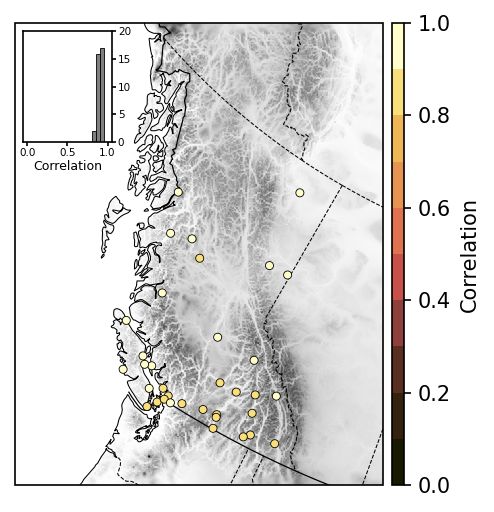

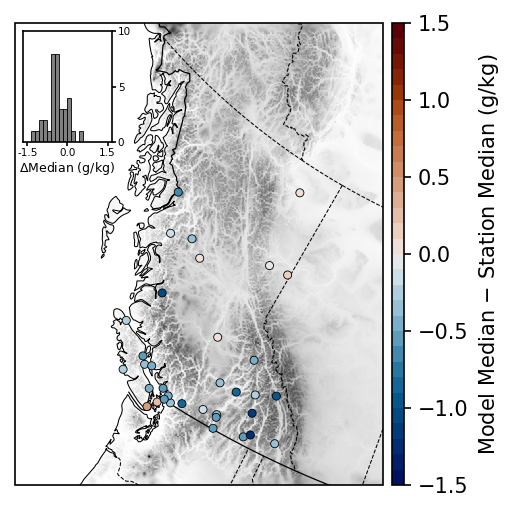

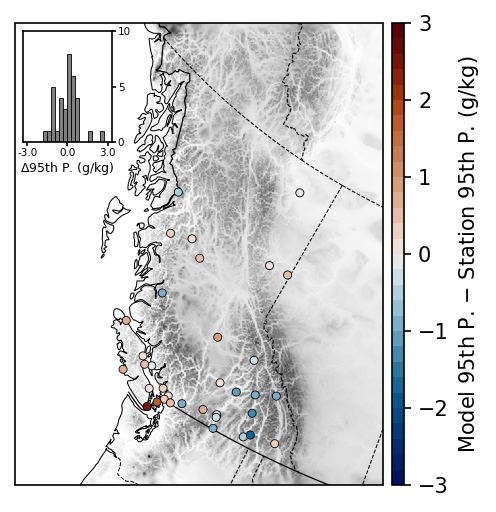

In [209]:
cmap_corr = ListedColormap(cm.lajolla(np.linspace(0, 1, 10)))
cmap_medbias = ListedColormap(cm.vik(np.linspace(0, 1, 30)))
cmap_95pbias = ListedColormap(cm.vik(np.linspace(0, 1, 30)))

plot_annual(corr_dict_ubc, cmap_corr, hist_bins=np.arange(0, 1+.05, .05), hist_xlabel="Correlation", cbar_label="Correlation", hist_yticks=[0, 5, 10, 15, 20])
plot_annual(bmedian_dict_ubc, cmap_medbias, hist_bins=np.arange(-1.5, 1.5+.15,.15), hist_xlabel=r'$\Delta$Median (g/kg)', cbar_label='Model Median $-$ Station Median (g/kg)', hist_yticks=[0, 5, 10])
plot_annual(b95p_dict_ubc, cmap_95pbias, hist_bins=np.arange(-3, 3+.3,.3), hist_xlabel=r'$\Delta$95th P. (g/kg)', cbar_label='Model 95th P. $-$ Station 95th P. (g/kg)', hist_yticks=[0, 5, 10])

DJF min=0.70 max=0.87
MAM min=0.74 max=0.87
JJA min=0.43 max=0.77
SON min=0.78 max=0.92


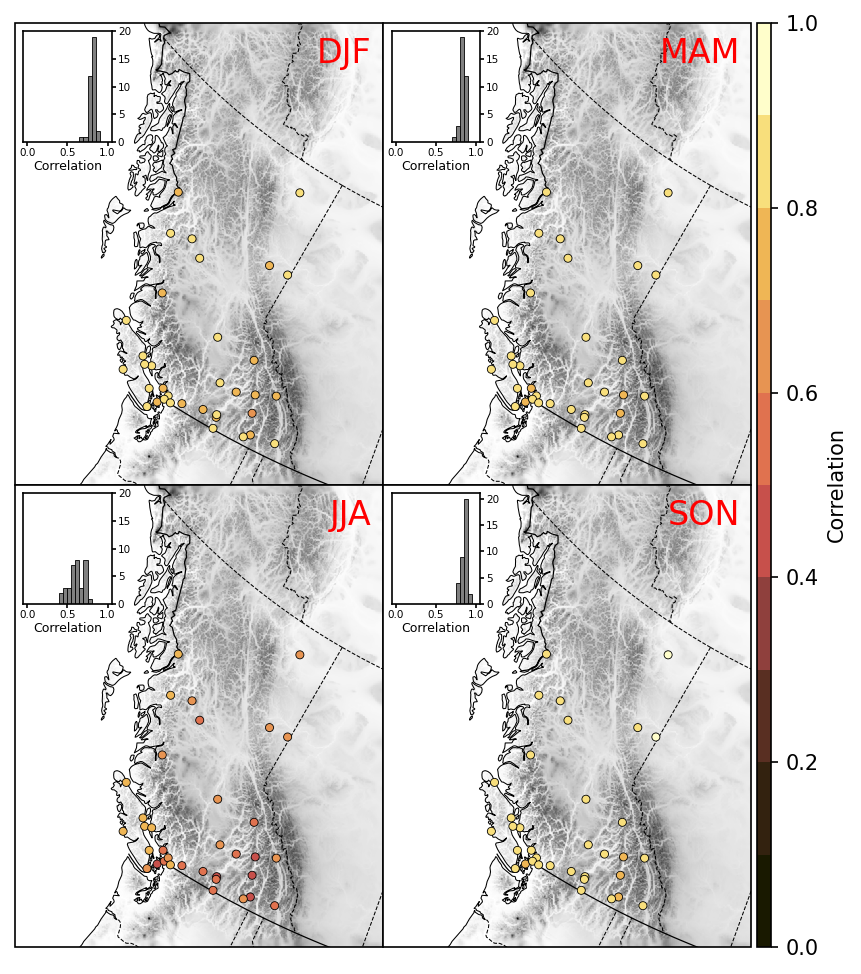

DJF min=-1.14 max=0.22
MAM min=-1.11 max=0.32
JJA min=-1.81 max=1.34
SON min=-1.68 max=0.64


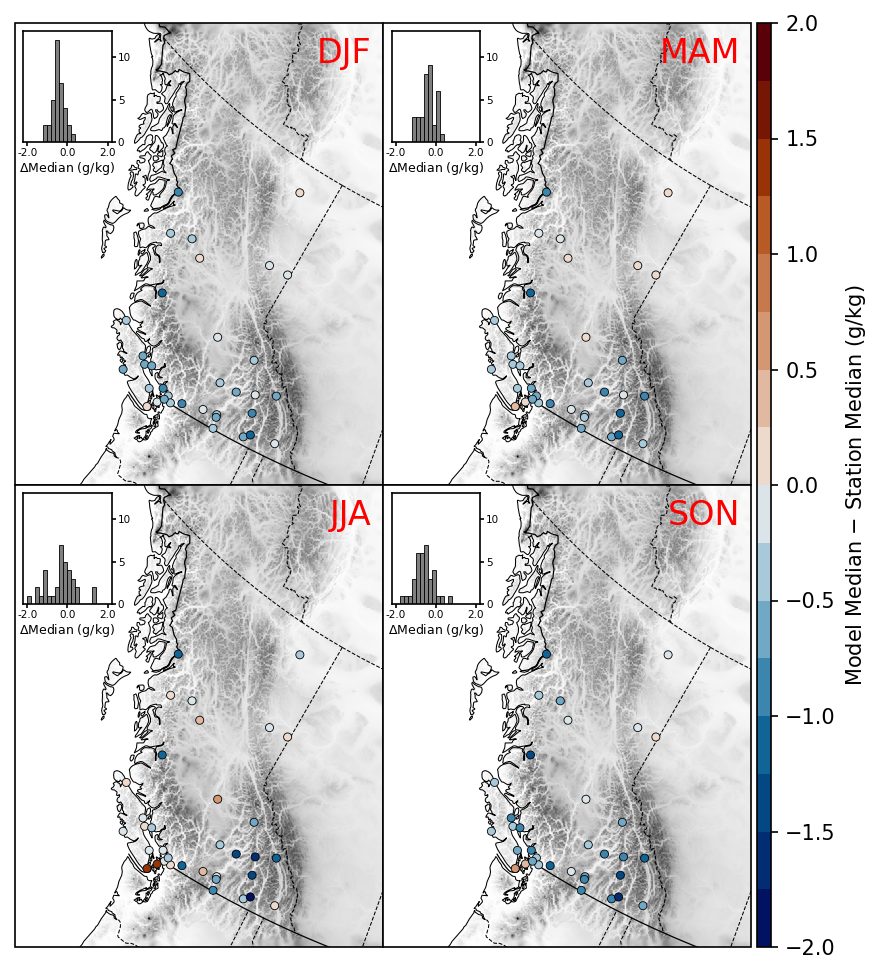

DJF min=-0.89 max=0.56
MAM min=-0.97 max=1.55
JJA min=-2.06 max=3.38
SON min=-2.07 max=1.96


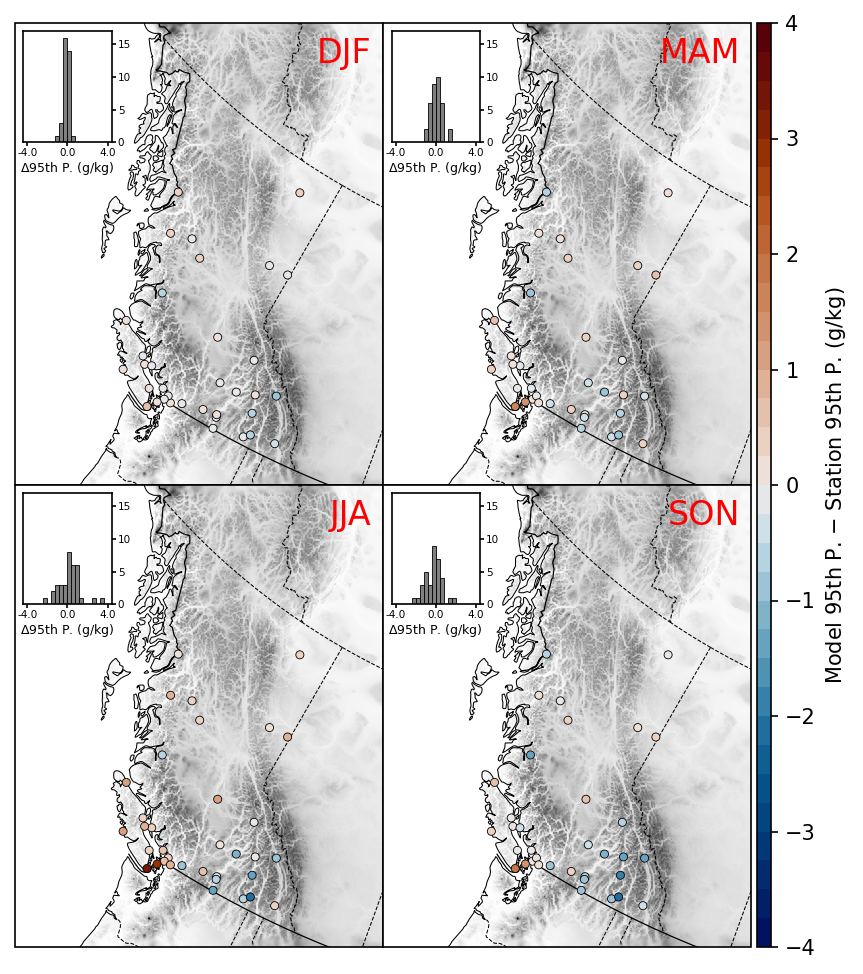

In [214]:
cmap_corr = ListedColormap(cm.lajolla(np.linspace(0, 1, 10)))
cmap_medbias = ListedColormap(cm.vik(np.linspace(0, 1, int(4/.25))))
cmap_95pbias = ListedColormap(cm.vik(np.linspace(0, 1, int(8/.25))))

plot_seasonal(corr_dict_ubc, cmap_corr, hist_bins=np.arange(0, 1+.05, .05), hist_xlabel="Correlation", cbar_label="Correlation", hist_yticks=[0, 5, 10, 15, 20])
plot_seasonal(bmedian_dict_ubc, cmap_medbias, hist_bins=np.arange(-2., 2.+.2,.2), hist_xlabel=r'$\Delta$Median (g/kg)', cbar_label='Model Median $-$ Station Median (g/kg)', hist_ylim=13, hist_yticks=[0, 5, 10])
plot_seasonal(b95p_dict_ubc, cmap_95pbias, hist_bins=np.arange(-4., 4.+.4,.4), hist_xlabel=r'$\Delta$95th P. (g/kg)', cbar_label='Model 95th P. $-$ Station 95th P. (g/kg)', hist_ylim=17, hist_yticks=[0, 5, 10, 15])

# Taylor Diagram

In [210]:
# # Set up the plot

# fig = plt.figure(figsize=(6, 6), dpi=120)
# ax = fig.add_subplot(111, polar=True)

# rlim = 2.0
# dr = .5
# ax.set_theta_zero_location('N')
# ax.set_theta_direction(-1)
# ax.set_rlabel_position(225)
# ax.set_ylabel('Standard Deviation (Normalized)')
# ax.set_yticks(np.arange(0, rlim + dr, dr))
# ax.set_ylim(0, rlim)
# ax.set_thetamin(0)
# ax.set_thetamax(90)

# corr_ticklabels = np.array([0,1,2,3,4,5,6,7,8,9,9.5,9.9,10])/10.
# corr_ticks = np.arcsin(corr_ticklabels)
# ax.set_thetagrids(np.degrees(corr_ticks), labels=corr_ticklabels)
# ax.grid(color='grey',linestyle='--')

# for i,diam in enumerate([0.5,1.0,1.5,2.0]):
#     circle = plt.Circle((1, 0), diam, transform=ax.transData._b, color='blue', fill=False, linewidth=1, linestyle=':')
#     ax.add_artist(circle)
#     if i < 2:
#         ax.text(
#             np.pi/2 - .05, 1.+diam, f"{diam:.1f}",
#             color='blue', fontsize=10, ha='center', va='bottom', rotation=0,
#             bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1')
#         )

# ax.text(np.pi/4, rlim - .1, 'Correlation Coefficient', color='k', fontsize=10, rotation=-45, zorder=9)
# ax.text(np.pi/2+.015, .96, '.', color='k', fontsize=40, rotation=0, zorder=9)
# ax.text(np.pi/2+.09, .945, 'Obsv.', color='k', fontsize=7, rotation=0, zorder=9)

# def plot_point(r, theta):
#     ax.scatter(np.pi/2 - theta, r, marker='o', facecolor='red', edgecolor='k', linewidth=.4, zorder=10)


# # Plot the data station by station

# std_norm, rms_norm, corr = [1.], [0.], [1.]

# for i, stn in enumerate(sorted(Q2_coverage_dict.keys())):

#     if i < 100:
#         # Get station data
#         print(f"({i+1}/{len(Q2_coverage_dict)}) Working on {stn}...")

#         data = get_stn(stn)
#         lat = stn_latlon[stn][0]
#         lon = stn_latlon[stn][1]
#         start_time = data.index.min().to_datetime64()
#         end_time = data.index.max().to_datetime64()
#         stn_humid = data["Specific Humidity (kg/kg)"].resample('D').mean()
#         stn_humid = stn_humid[stn_humid.index < '2023-10-01T00:00:00.000000000']

#         for year, month in BAD_MONTHS:
#             stn_humid = stn_humid[~((stn_humid.index.year == year) & (stn_humid.index.month == month))]

#         # Get model data nearest the station
#         nearest_idx = get_nearest_wrf_point(humid_ds, lat, lon)
#         wrf_humid = humid_ds.isel(south_north=nearest_idx[0], west_east=nearest_idx[1])

#         for year, month in BAD_MONTHS:
#             wrf_humid = wrf_humid.sel(time=~((wrf_humid.time.dt.year == year) & (wrf_humid.time.dt.month == month)))

#         # turn into numpy arrays
#         stn_humid = stn_humid.values
#         wrf_humid = wrf_humid['Q2'].values

#         # remove nans
#         wrf_humid = wrf_humid[~np.isnan(stn_humid)]
#         stn_humid = stn_humid[~np.isnan(stn_humid)]

#         # taylor statistics
#         stats = sm.taylor_statistics(wrf_humid, stn_humid)
#         std_norm.append(stats['sdev'][1] / stats['sdev'][0])
#         rms_norm.append(stats['crmsd'][1] / stats['sdev'][0])
#         corr.append(stats['ccoef'][1])
#         if corr[-1] < 0:
#             print(f"WARNING: Negative Correlation Detected for Station {stn}")

#         # plot
#         plot_point(std_norm[-1], np.arccos(corr[-1]))

# plt.show()